In [ ]:
!pip -q install qai-hub-models opencv-python-headless mediapipe scipy imageio imageio-ffmpeg matplotlib
print("install done")



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.9/103.9 kB 9.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.6/503.6 kB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.7/117.7 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 129.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
import cv2
import math
import imageio
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
from google.colab import files
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

from qai_hub_models.models.facemap_3dmm.model import FaceMap_3DMM
from qai_hub_models.models.facemap_3dmm.utils import project_landmark

WORK_DIR = "/content/facemap_reenact"
os.makedirs(WORK_DIR, exist_ok=True)
FRAMES_DIR = f"{WORK_DIR}/driving_frames"
OUT_DIR = f"{WORK_DIR}/reenacted_frames"
os.makedirs(FRAMES_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

MODEL_INPUT_SIZE = 128
CROP_SIZE = 256

model = FaceMap_3DMM.from_pretrained()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

MP_TASK_PATH = f"/content/face_landmarker.task"
if not os.path.exists(MP_TASK_PATH):
    !wget -q --show-progress -O {MP_TASK_PATH} https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task

base_options = python.BaseOptions(model_asset_path=MP_TASK_PATH)
landmarker_options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_faces=1,
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False,
)
face_landmarker = vision.FaceLandmarker.create_from_options(landmarker_options)

print("model ready")


model ready


In [ ]:
def detect_face_mesh_and_bbox_bgr(image_bgr, pad_ratio=0.35):
    h, w = image_bgr.shape[:2]
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    detection_result = face_landmarker.detect(mp_image)

    if not detection_result.face_landmarks:
        return None, None

    landmarks_proto = detection_result.face_landmarks[0]
    landmarks = np.array(
        [[pt.x * w, pt.y * h] for pt in landmarks_proto],
        dtype=np.float32
    )

    x1 = int(np.min(landmarks[:, 0]))
    y1 = int(np.min(landmarks[:, 1]))
    x2 = int(np.max(landmarks[:, 0]))
    y2 = int(np.max(landmarks[:, 1]))
    bw = x2 - x1
    bh = y2 - y1

    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0
    size = max(bw, bh) * (1.0 + pad_ratio)
    half = size / 2.0

    x1 = max(0, int(cx - half))
    y1 = max(0, int(cy - half))
    x2 = min(w, int(cx + half))
    y2 = min(h, int(cy + half))

    return landmarks, (x1, y1, x2, y2)


def crop_square(image_bgr, bbox, crop_size=CROP_SIZE):
    x1, y1, x2, y2 = bbox
    crop = image_bgr[y1:y2, x1:x2]
    if crop.size == 0:
        raise ValueError(f"Invalid crop bbox: {bbox}")
    crop = cv2.resize(crop, (crop_size, crop_size))
    return crop


def to_model_input(crop_bgr):
    resized = cv2.resize(crop_bgr, (MODEL_INPUT_SIZE, MODEL_INPUT_SIZE))
    rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
    tensor = rgb.astype(np.float32) / 255.0
    tensor = torch.from_numpy(tensor).permute(2, 0, 1).unsqueeze(0).contiguous()
    return tensor


def infer_coeff(crop_bgr):
    model_input = to_model_input(crop_bgr).to(device)
    with torch.no_grad():
        output = model(model_input)
        if isinstance(output, (list, tuple)):
            output = output[0]
        coeff = output[0].float().detach().cpu()

    if coeff.shape[0] > 264:
        coeff = coeff[:264]
    return coeff


def coeff_to_landmarks(coeff, crop_size=CROP_SIZE):
    if not torch.is_tensor(coeff):
        coeff = torch.from_numpy(np.asarray(coeff)).float()
    coeff = coeff.detach().cpu().float()

    with torch.no_grad():
        points = project_landmark(coeff).detach().cpu().numpy().astype(np.float32)

    points[:, 0] = (points[:, 0] + MODEL_INPUT_SIZE / 2.0) * crop_size / MODEL_INPUT_SIZE
    points[:, 1] = (points[:, 1] + MODEL_INPUT_SIZE / 2.0) * crop_size / MODEL_INPUT_SIZE
    return points


def mix_coeff(source_coeff, driving_coeff):
    if not torch.is_tensor(source_coeff):
        source_coeff = torch.from_numpy(np.asarray(source_coeff)).float()
    if not torch.is_tensor(driving_coeff):
        driving_coeff = torch.from_numpy(np.asarray(driving_coeff)).float()

    source_coeff = source_coeff.detach().cpu().float()
    driving_coeff = driving_coeff.detach().cpu().float()

    mixed = source_coeff.clone()
    mixed[219:264] = driving_coeff[219:264]
    return mixed



def apply_affine(src, src_tri, dst_tri, output, mask):
    src_rect = cv2.boundingRect(np.float32([src_tri]))
    dst_rect = cv2.boundingRect(np.float32([dst_tri]))

    x1, y1, w1, h1 = src_rect
    x2, y2, w2, h2 = dst_rect
    if min(w1, h1, w2, h2) <= 0:
        return

    src_crop = src[y1:y1 + h1, x1:x1 + w1]
    src_tri_local = np.float32([[p[0] - x1, p[1] - y1] for p in src_tri])
    dst_tri_local = np.float32([[p[0] - x2, p[1] - y2] for p in dst_tri])

    warp_mat = cv2.getAffineTransform(src_tri_local, dst_tri_local)
    warped = cv2.warpAffine(
        src_crop,
        warp_mat,
        (w2, h2),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT_101,
    )

    tri_mask = np.zeros((h2, w2, 3), dtype=np.float32)
    cv2.fillConvexPoly(tri_mask, np.int32(dst_tri_local), (1.0, 1.0, 1.0), 16, 0)

    output[y2:y2 + h2, x2:x2 + w2] = (
        output[y2:y2 + h2, x2:x2 + w2] * (1.0 - tri_mask)
        + warped * tri_mask
    )
    mask[y2:y2 + h2, x2:x2 + w2] = np.maximum(mask[y2:y2 + h2, x2:x2 + w2], tri_mask)


def warp_face(source_crop, src_points, dst_points):
    src_points = np.clip(src_points, 0, CROP_SIZE - 1)
    dst_points = np.clip(dst_points, 0, CROP_SIZE - 1)

    tri = Delaunay(dst_points)
    output = np.zeros_like(source_crop, dtype=np.float32)
    mask = np.zeros_like(source_crop, dtype=np.float32)

    for simplex in tri.simplices:
        src_tri = src_points[simplex]
        dst_tri = dst_points[simplex]
        apply_affine(source_crop, src_tri, dst_tri, output, mask)

    base = source_crop.astype(np.float32)
    blended = output + base * (1.0 - mask)
    return np.clip(blended, 0, 255).astype(np.uint8)


print("helpers ready")


helpers ready


Upload source image


Saving ek.jpeg to ek (2).jpeg
Upload driving video


Saving result_faceswap (2).mp4 to result_faceswap (2) (2).mp4
driving frames: 78 fps: 25.0


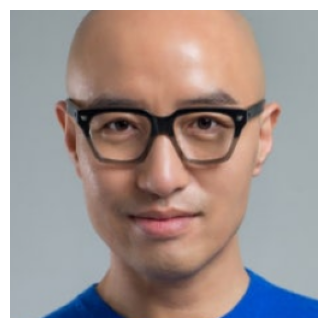

In [ ]:
print("Upload source image")
source_upload = files.upload()
SOURCE_PATH = next(iter(source_upload.keys()))

print("Upload driving video")
driving_upload = files.upload()
DRIVING_PATH = next(iter(driving_upload.keys()))

# source 처리
source_image = cv2.imread(SOURCE_PATH)
assert source_image is not None, "source image load 실패"

source_landmarks, source_bbox = detect_face_mesh_and_bbox_bgr(source_image)
assert source_bbox is not None, "No face found in source image."

source_crop = crop_square(source_image, source_bbox)

source_coeff = infer_coeff(source_crop)
source_points = coeff_to_landmarks(source_coeff)

# driving video 열기
cap = cv2.VideoCapture(DRIVING_PATH)
fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("driving frames:", frame_count, "fps:", fps)

# preview
preview = cv2.cvtColor(source_crop, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(4, 4))
plt.imshow(preview)
plt.axis("off")
plt.show()

In [ ]:
frame_index = 0
saved_paths = []

cap = cv2.VideoCapture(DRIVING_PATH)

while True:
    ok, frame = cap.read()
    if not ok:
        break

    # Change from detect_face_bbox_bgr to detect_face_mesh_and_bbox_bgr
    # and handle the two return values
    _, bbox = detect_face_mesh_and_bbox_bgr(frame)

    if bbox is None:
        reenacted = source_crop.copy()
    else:
        driving_crop = crop_square(frame, bbox)
        driving_coeff = infer_coeff(driving_crop)

        mixed_coeff = mix_coeff(source_coeff, driving_coeff)
        mixed_points = coeff_to_landmarks(mixed_coeff)

        reenacted = warp_face(source_crop, source_points, mixed_points)

    out_path = f"{OUT_DIR}/frame_{frame_index:05d}.png"
    cv2.imwrite(out_path, reenacted)
    saved_paths.append(out_path)

    frame_index += 1

    if frame_index % 25 == 0:
        print("processed", frame_index)

cap.release()
print("saved frames:", len(saved_paths))

processed 25
processed 50
processed 75
saved frames: 78


In [ ]:
OUTPUT_VIDEO = f"{WORK_DIR}/reenacted_face_only.mp4"

writer = imageio.get_writer(OUTPUT_VIDEO, fps=fps)

for path in saved_paths:
    frame = cv2.imread(path)
    writer.append_data(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

writer.close()

print("video saved:", OUTPUT_VIDEO)
files.download(OUTPUT_VIDEO)

video saved: /content/facemap_reenact/reenacted_face_only.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
sample_ids = np.linspace(0, len(saved_paths) - 1, num=min(5, len(saved_paths)), dtype=int)

plt.figure(figsize=(15, 3))

for i, idx in enumerate(sample_ids, 1):
    frame = cv2.imread(saved_paths[idx])
    plt.subplot(1, len(sample_ids), i)
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(idx)

plt.tight_layout()
plt.show()